In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

In [19]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [20]:
X

array([[-3.52813037,  3.88999555],
       [ 7.65035304,  9.03248871],
       [ 5.15493532,  9.56190612],
       ...,
       [ 3.57076675, -1.82552732],
       [ 9.57614069,  7.8713817 ],
       [ 2.20258324, -2.59144261]])

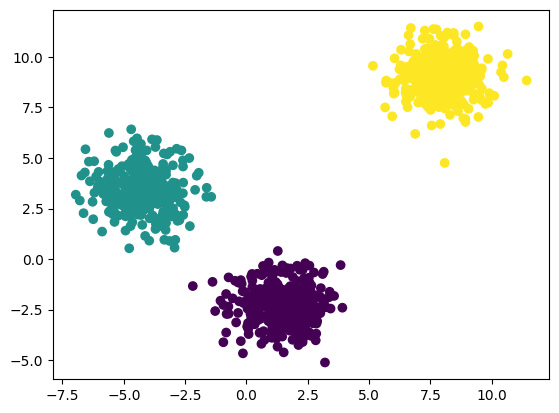

In [21]:
plt.scatter(X[:,0],X[:,1],c=y)

In [22]:
# Splitting the Data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [23]:
# Scaling the Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
from sklearn.cluster import KMeans

In [26]:
# Elbow Method to Select K value
wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

In [27]:
wcss

[1340.0,
 360.06834349791495,
 55.31814438620036,
 49.49748545243186,
 43.951086987063704,
 38.02901328667144,
 32.58081215822459,
 28.42758381400995,
 25.744117206221816,
 23.206932002516034]

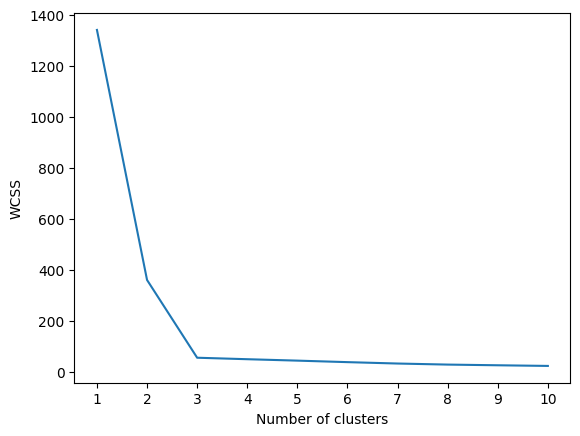

In [28]:
# Plotting WCSS over K values
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [29]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [30]:
kmeans.fit_predict(X_train_scaled)

array([0, 2, 1, 0, 2, 2, 2, 1, 2, 1, 2, 2, 0, 1, 2, 0, 1, 1, 1, 0, 0, 2,
       0, 0, 0, 2, 0, 2, 0, 0, 2, 1, 1, 0, 2, 1, 0, 1, 2, 1, 1, 0, 0, 1,
       0, 0, 2, 0, 2, 1, 1, 2, 1, 0, 2, 2, 2, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 2, 2, 1, 1, 0, 0, 2, 2, 0, 1, 0, 1, 1, 2, 2, 1, 2, 2, 1, 0, 2,
       2, 1, 2, 2, 1, 2, 1, 0, 2, 1, 2, 1, 2, 1, 0, 0, 0, 0, 2, 0, 1, 1,
       1, 2, 1, 2, 1, 2, 2, 1, 0, 0, 2, 1, 2, 2, 2, 2, 1, 1, 2, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 2, 0, 0, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 0, 1,
       2, 0, 0, 1, 1, 2, 2, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 2, 2, 1,
       1, 2, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 1, 2, 0, 1, 2, 2, 0, 0, 0, 2,
       1, 2, 2, 0, 1, 0, 0, 1, 1, 2, 1, 0, 1, 0, 2, 0, 1, 0, 1, 1, 2, 2,
       2, 0, 0, 1, 1, 0, 0, 0, 2, 1, 0, 1, 1, 1, 0, 0, 2, 2, 1, 0, 1, 2,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 2, 2, 0, 1, 0, 0, 1,
       2, 2, 0, 0, 0, 1, 2, 0, 2, 1, 1, 1, 0, 1, 2, 2, 0, 2, 2, 1, 1, 2,
       1, 1, 1, 1, 2, 1, 0, 0, 0, 0, 1, 1, 2, 0, 1,

In [31]:
y_pred=kmeans.predict(X_test_scaled)

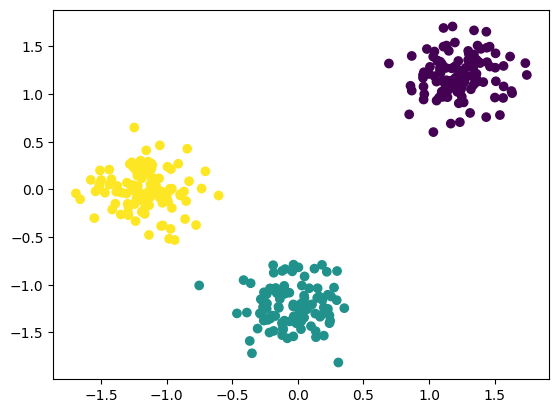

In [43]:
plt.scatter(X_test_scaled[:,0],X_test_scaled[:,1],c=y_pred)

In [33]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [34]:
## kneelocator
!pip install kneed

In [40]:
from kneed import KneeLocator

In [41]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [42]:
kl.elbow

np.int64(3)

In [35]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [36]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [37]:
silhouette_coefficients

[np.float64(0.7048528626095723),
 np.float64(0.8068223616585201),
 np.float64(0.6553839623173419),
 np.float64(0.49996537075456843),
 np.float64(0.4866992765274375),
 np.float64(0.3152312789079249),
 np.float64(0.3306340289389886),
 np.float64(0.3405800783360416),
 np.float64(0.3428690729240507)]

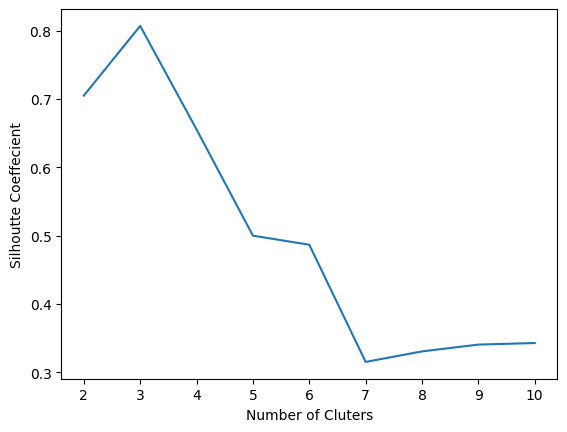

In [38]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()